In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("202601_202606_연령별인구현황_월간.csv", encoding="cp949")

In [7]:
df.head()

,행정구역,2026년01월_거주자_총인구수,2026년01월_거주자_연령구간인구수,2026년01월_거주자_0~9세,2026년01월_거주자_10~19세,2026년01월_거주자_20~29세,2026년01월_거주자_30~39세,2026년01월_거주자_40~49세,2026년01월_거주자_50~59세,2026년01월_거주자_60~69세,...,2026년06월_여_거주자_10~19세,2026년06월_여_거주자_20~29세,2026년06월_여_거주자_30~39세,2026년06월_여_거주자_40~49세,2026년06월_여_거주자_50~59세,2026년06월_여_거주자_60~69세,2026년06월_여_거주자_70~79세,2026년06월_여_거주자_80~89세,2026년06월_여_거주자_90~99세,2026년06월_여_거주자_100세 이상
0,서울특별시 강남구 (1168000000),"548,767","548,767","31,839","63,729","62,434","79,541","98,437","86,861","62,427",...,"30,428","32,508","41,641","53,105","43,620","32,885","24,779","9,373","1,967",68
1,서울특별시 강남구 신사동(1168051000),"14,759","14,759",778,"1,441","1,742","1,893","2,298","2,541","1,717",...,750,924,"1,001","1,227","1,343",889,813,420,81,5
2,서울특별시 강남구 논현1동(1168052100),"20,080","20,080",479,822,"3,300","5,152","3,417","2,688","2,055",...,411,"1,834","2,537","1,833","1,350","1,105",836,358,62,3
3,서울특별시 강남구 논현2동(1168053100),"19,600","19,600",778,"1,168","2,732","4,024","3,483","3,024","2,056",...,582,"1,507","2,123","1,860","1,582","1,100",905,390,72,4
4,서울특별시 강남구 압구정동(1168054500),"25,042","25,042","1,696","2,734","2,553","2,722","4,089","4,172","3,115",...,"1,415","1,319","1,478","2,236","2,201","1,628","1,451",681,140,3


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Columns: 235 entries, 행정구역 to 2026년06월_여_거주자_100세 이상
dtypes: int64(24), str(211)
memory usage: 42.4 KB


In [9]:
df.columns

Index(['행정구역', '2026년01월_거주자_총인구수', '2026년01월_거주자_연령구간인구수',
       '2026년01월_거주자_0~9세', '2026년01월_거주자_10~19세', '2026년01월_거주자_20~29세',
       '2026년01월_거주자_30~39세', '2026년01월_거주자_40~49세', '2026년01월_거주자_50~59세',
       '2026년01월_거주자_60~69세',
       ...
       '2026년06월_여_거주자_10~19세', '2026년06월_여_거주자_20~29세',
       '2026년06월_여_거주자_30~39세', '2026년06월_여_거주자_40~49세',
       '2026년06월_여_거주자_50~59세', '2026년06월_여_거주자_60~69세',
       '2026년06월_여_거주자_70~79세', '2026년06월_여_거주자_80~89세',
       '2026년06월_여_거주자_90~99세', '2026년06월_여_거주자_100세 이상'],
      dtype='str', length=235)

In [10]:
# 첫번째 행이 강남구고 그 다음부터 동이라서 첫번째 행을 빼는게 좋음
dong_df = df.iloc[1:].copy()

In [11]:
columns = [
    "행정구역",
    "2026년06월_거주자_총인구수",
    "2026년06월_거주자_0~9세",
    "2026년06월_거주자_10~19세",
    "2026년06월_거주자_20~29세",
    "2026년06월_거주자_30~39세",
    "2026년06월_거주자_40~49세",
    "2026년06월_거주자_50~59세",
    "2026년06월_거주자_60~69세",
    "2026년06월_거주자_70~79세",
    "2026년06월_거주자_80~89세",
    "2026년06월_거주자_90~99세",
    "2026년06월_거주자_100세 이상"
]

dong_df = dong_df[columns]

In [12]:
#데이터가 14,697처럼 ,가 있어서 바꿔줘야함. -> 데이터 전처리
for col in dong_df.columns[1:]:
    dong_df[col] = (
        dong_df[col]
        .astype(str)
        .str.replace(",", "")
        .astype(int)
    )

In [ ]:
#동 이름이 서울특별시 강남구 신사동(번호) 이렇게 길어서 이걸 신사동 이렇게 짧게 만들어주는 과정
dong_df["동이름"] = (
    dong_df["행정구역"]
    .str.extract(r"강남구\s+([^(]+)")[0]
    .str.strip()
)

In [14]:
dong_df[["행정구역", "동이름"]].head()

,행정구역,동이름
1,서울특별시 강남구 신사동(1168051000),신사동
2,서울특별시 강남구 논현1동(1168052100),논현1동
3,서울특별시 강남구 논현2동(1168053100),논현2동
4,서울특별시 강남구 압구정동(1168054500),압구정동
5,서울특별시 강남구 청담동(1168056500),청담동


이제 이걸 코드로 볼꺼면 터미널에
- sudo apt update
- sudo apt install fonts-nanum
한 후

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
이걸 사용

In [17]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

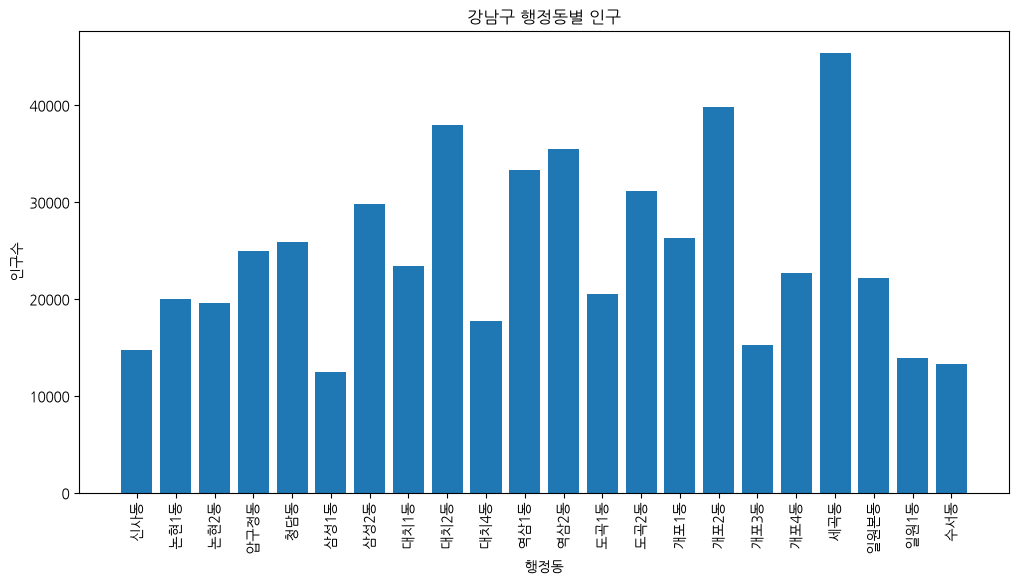

In [18]:
plt.figure(figsize=(12, 6))

plt.bar(
    dong_df["동이름"],
    dong_df["2026년06월_거주자_총인구수"]
)

plt.title("강남구 행정동별 인구")
plt.xlabel("행정동")
plt.ylabel("인구수")

plt.xticks(rotation=90)

plt.show()

In [21]:
# 위 그래프는 시각적으로 잘 안보임. 인구순으로 정렬한 후 보면 더 좋음.
sorted_df = dong_df.sort_values(
    "2026년06월_거주자_총인구수",
    ascending=False
)

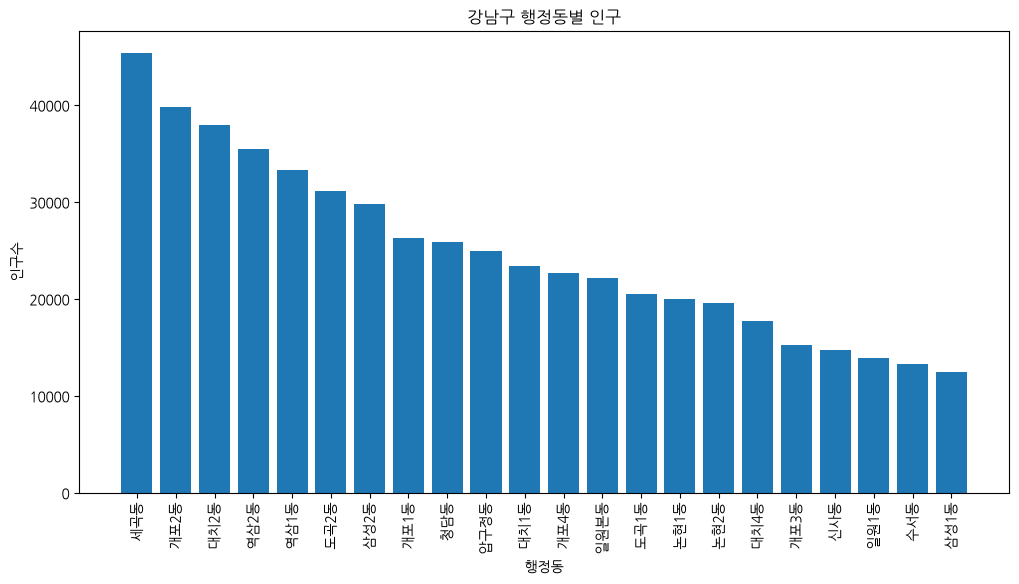

In [20]:
plt.figure(figsize=(12, 6))

plt.bar(
    sorted_df["동이름"],
    sorted_df["2026년06월_거주자_총인구수"]
)

plt.title("강남구 행정동별 인구")
plt.xlabel("행정동")
plt.ylabel("인구수")

plt.xticks(rotation=90)

plt.show()

Folium 지도 위에 각 동의 중심 좌표를 찍고, CircleMarker에 tooltip을 넣는 방식 사용해보기
- uv add folium geopy

In [25]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(
    user_agent="gangnam_population_map",
    timeout=10
)

geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=1,
    max_retries=2,
    error_wait_seconds=2,
    swallow_exceptions=True
)

In [26]:
dong_df["주소"] = (
    "서울 강남구 "
    + dong_df["동이름"]
)

In [27]:
dong_df["location"] = dong_df["주소"].apply(geocode)

In [28]:
dong_df["위도"] = dong_df["location"].apply(
    lambda x: x.latitude if x else None
)

dong_df["경도"] = dong_df["location"].apply(
    lambda x: x.longitude if x else None
)

In [29]:
dong_df[dong_df["위도"].isna()][["동이름", "주소"]]

,동이름,주소


In [30]:
dong_df.to_csv(
    "gangnam_population_with_location.csv",
    index=False,
    encoding="utf-8-sig"
)

In [31]:
dong_df = pd.read_csv("gangnam_population_with_location.csv")

In [32]:
dong_df[["동이름", "위도", "경도"]]

,동이름,위도,경도
0,신사동,37.522321,127.027702
1,논현1동,37.511867,127.026302
2,논현2동,37.513730,127.036716
3,압구정동,37.530043,127.031335
4,청담동,37.525754,127.052322
5,삼성1동,37.516043,127.059793
6,삼성2동,37.513730,127.047821
7,대치1동,37.494061,127.058679
8,대치2동,37.500274,127.066666
9,대치4동,37.501679,127.054869


In [33]:
import folium

m = folium.Map(
    location=[37.50, 127.05],
    zoom_start=13
)

population_col = "2026년06월_거주자_총인구수"

max_population = dong_df[population_col].max()

for _, row in dong_df.dropna(subset=["위도", "경도"]).iterrows():

    population = row[population_col]

    radius = population / max_population * 20 + 5

    folium.CircleMarker(
        location=[row["위도"], row["경도"]],
        radius=radius,
        tooltip=(
            f'<b>{row["동이름"]}</b><br>'
            f'인구: {population:,}명'
        ),
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

In [38]:
m.save("gangnam_population_map.html")

explorer.exe gangnam_population_map.html
- 위 코드를 터미널에 입력하면 웹창으로 지도가 나옴.